In [62]:
from statistics import mean
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

In [63]:
with open('/home/yaning/Documents/Discounting/paper/results/parameter_recovery_square_root.pkl', 'rb') as f:
    pos_dict = pickle.load(f)

In [64]:
# get the real and inferred params from more agents
real_params = []
inferred_params = []
real_params = pos_dict['real_param']
inferred_params = pos_dict['inferred_param']['m_locs']

In [65]:
print(real_params.shape)
print(inferred_params.shape)

(100, 2)
(100, 2)


In [66]:
# # --------for tanh and four param------------------
# real_a = real_params[:,1]
# inferred_a = inferred_params[:,1]

# real_b = real_params[:,2]
# inferred_b = inferred_params[:,2]

# real_sigma_rate = real_params[:,0]
# inferred_sigma_rate = inferred_params[:,0]

# real_beta = real_params[:,3]
# inferred_beta = inferred_params[:,3]

# #-----------three param------------
# real_b = real_params[:,1]
# inferred_b = inferred_params[:,1]

# real_sigma_rate = real_params[:,0]
# inferred_sigma_rate = inferred_params[:,0]

# real_beta = real_params[:,2]
# inferred_beta = inferred_params[:,2]

# --------for tanh------------------

real_sigma_rate = real_params[:,0]
inferred_sigma_rate = inferred_params[:,0]

real_beta = real_params[:,1]
inferred_beta = inferred_params[:,1]


In [67]:
def same_range(ax, x, y):
    # Calculate the maximum range between x and y
    list = np.concatenate((x,y))

    max_range = max(list) - min(list)

    # Calculate the center of the plot
    center = (max(list) + min(list)) / 2

    # Set the limits of both axes with the same range around the center
    small = center - max_range / 1.7
    big = center + max_range / 1.7
    ax.set_xlim(small, big)
    ax.set_ylim(small, big)

    # ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Diagonal Line')

In [68]:
# put everything to lists so it is easier to plot
real_list = [#real_a, 
#real_b, 
real_sigma_rate, real_beta]
inferred_list = [#inferred_a, 
#inferred_b, 
inferred_sigma_rate, inferred_beta]

# try dataframe instead
df = pd.DataFrame({
    # 'real_a': real_a,
    # 'real_b': real_b,
    'real_sigma_u': real_sigma_rate,
    'real_beta': real_beta,
    # 'inferred_a': inferred_a,
    # 'inferred_b': inferred_b,
    'inferred_sigma_u': inferred_sigma_rate,
    'inferred_beta': inferred_beta
})

In [69]:
name_list = [#'real_a','inferred_a',
#'real_b','inferred_b', 
'real_sigma_u','inferred_sigma_u', 'real_beta','inferred_beta']

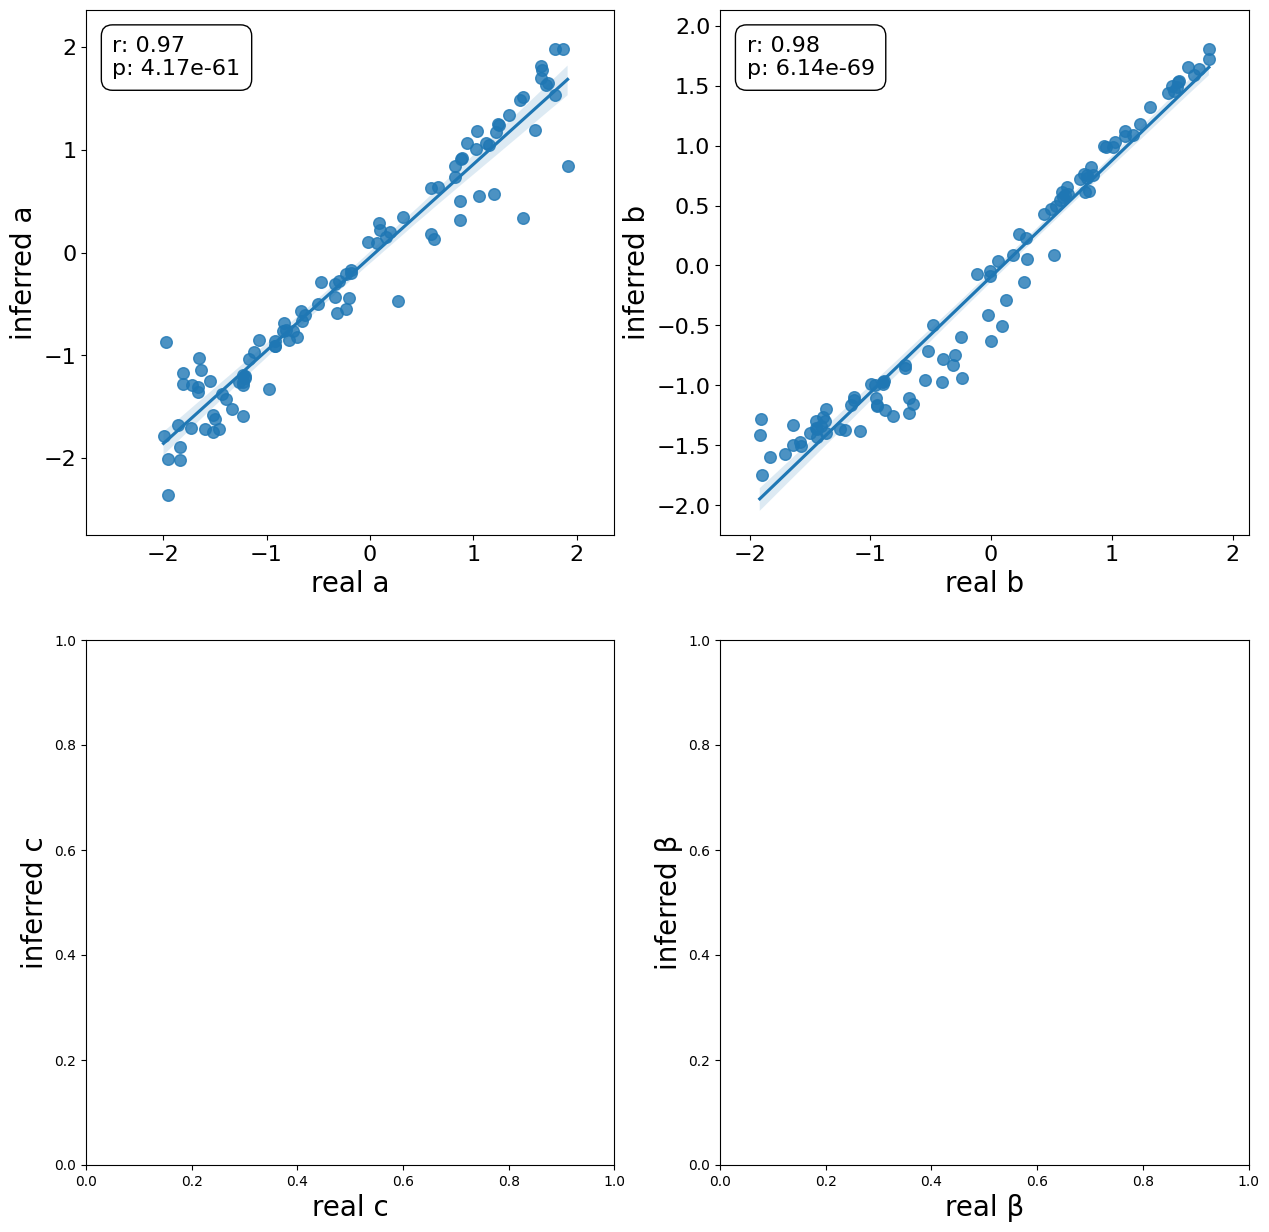

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
sub_x = 0
sub_y = 0
for i in range(len(real_list)):
    x_name = name_list[i*2]
    y_name = name_list[i*2+1]
    temp_ax = axes[sub_x, sub_y]
    sns.regplot(ax=temp_ax, x=x_name, y=y_name, data=df, scatter_kws={'s':70})
    same_range(temp_ax, df[x_name], df[y_name])
    corr_coeff, p_value = pearsonr(df[x_name], df[y_name])

    axes[sub_x, sub_y].annotate(f'r: {corr_coeff:.2f}\np: {p_value:.2e}', xy=(0.05, 0.95), xycoords='axes fraction', 
                fontsize=16, ha='left', va='top', bbox=dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='white'))
    
    if sub_y == 1:
        sub_x = sub_x + 1
        sub_y = 0
    else:
        sub_y = sub_y + 1

    temp_ax.tick_params(axis='both', labelsize=16)

axes[0,0].set_xlabel("real a", fontsize=20)
axes[0,0].set_ylabel("inferred a", fontsize=20)
axes[0,1].set_xlabel("real b", fontsize=20)
axes[0,1].set_ylabel("inferred b", fontsize=20)
axes[1,0].set_xlabel("real c", fontsize=20)
axes[1,0].set_ylabel("inferred c", fontsize=20)
axes[1,1].set_xlabel("real β", fontsize=20)
axes[1,1].set_ylabel("inferred β", fontsize=20)

plt.show()
plt.close()

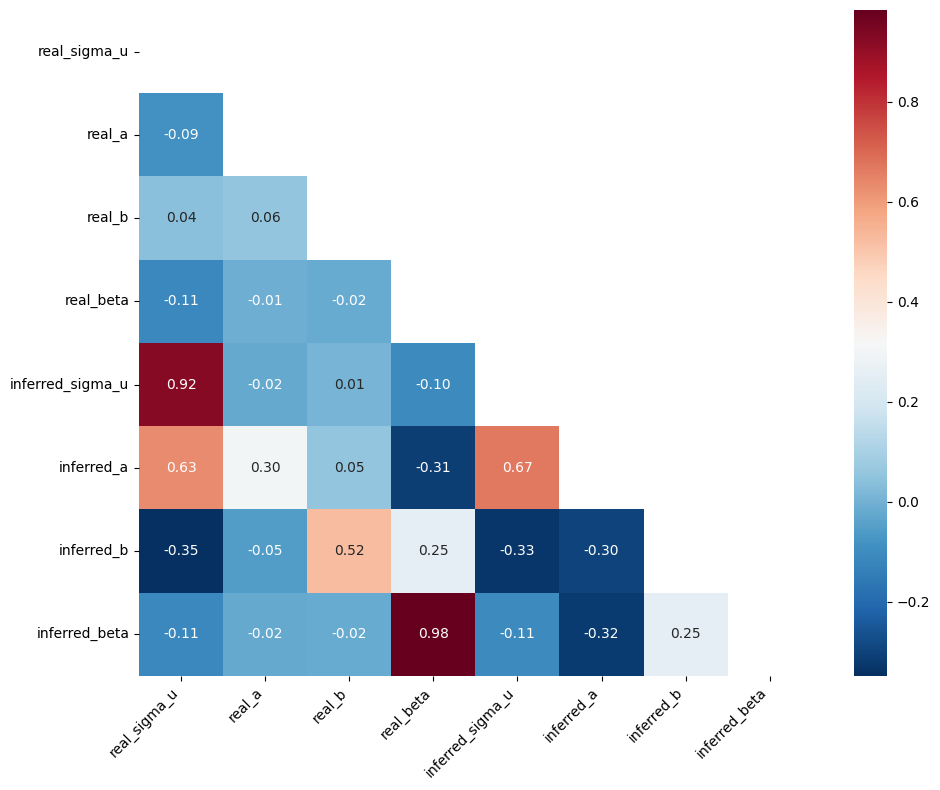

In [423]:
# -----------------------------correlation--------------------------------------
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, mask=mask, fmt=".2f", cmap='RdBu_r', annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# plot the posterior with simulated data
# fig = plt.figure(constrained_layout=False, figsize=(12,6))
# gs = fig.add_gridspec(nrows=2, ncols=4, left=0.05, right=0.95, wspace=0.35, hspace=0.35)

# ------------------------------shift model-------------------------------------------------
# ax1 = fig.add_subplot(gs[0,0], xlabel = 'real_mean_u', ylabel = 'infered_mean_u')
# ax2 = fig.add_subplot(gs[0,1], xlabel = 'real_sigma_u', ylabel = 'infered_sigma_u')
# ax3 = fig.add_subplot(gs[0,2], xlabel = 'real_sigma_es', ylabel = 'infered_sigma_es')
# ax4 = fig.add_subplot(gs[0,3], xlabel = 'real_beta', ylabel = 'infered_beta')
# ax5 = fig.add_subplot(gs[1,0], xlabel = 'real_shift_mean_u', ylabel = 'infered_shift_mean_sigma_u')
# ax6 = fig.add_subplot(gs[1,1], xlabel = 'real_shift_sigma_u', ylabel = 'infered_shift_sigma_u')
# ax7 = fig.add_subplot(gs[1,2], xlabel = 'real_shift_sigma_es', ylabel = 'infered_shift_sigma_es')

# ax1.scatter(real_mean_u, inferred_mean_u)
# ax2.scatter(real_sigma_u, inferred_sigma_u)
# ax3.scatter(real_sigma_es, inferred_sigma_es)
# ax4.scatter(real_beta, inferred_beta)
# ax5.scatter(real_shift_mean_u, inferred_shift_mean_u)
# ax6.scatter(real_shift_sigma_u, inferred_shift_sigma_u)
# ax7.scatter(real_shift_sigma_es, inferred_shift_sigma_es)

# same_range(ax1, real_mean_u, inferred_mean_u)
# same_range(ax2, real_sigma_u, inferred_sigma_u)
# same_range(ax3, real_sigma_es, inferred_sigma_es)
# same_range(ax4, real_beta, inferred_beta)
# same_range(ax5, real_shift_mean_u, inferred_shift_mean_u)
# same_range(ax6, real_shift_sigma_u, inferred_shift_sigma_u)
# same_range(ax7, real_shift_sigma_es, inferred_shift_sigma_es)

# ----------------------------time perception model-------------------------------------
# axes = []
# axes.append(fig.add_subplot(gs[0,0], xlabel = 'real_mean_u', ylabel = 'infered_mean_u'))
# axes.append(fig.add_subplot(gs[0,1], xlabel = 'real_sigma_u', ylabel = 'infered_sigma_u'))
# # axes.append(fig.add_subplot(gs[0,2], xlabel = 'real_sigma_es', ylabel = 'infered_sigma_es'))
# axes.append(fig.add_subplot(gs[0,3], xlabel = 'real_a', ylabel = 'infered_a'))
# axes.append(fig.add_subplot(gs[1,0], xlabel = 'real_b', ylabel = 'infered_b'))
# # axes.append(fig.add_subplot(gs[1,1], xlabel = 'real_c', ylabel = 'infered_c'))
# axes.append(fig.add_subplot(gs[1,2], xlabel = 'real_beta', ylabel = 'infered_beta'))


<Figure size 640x480 with 0 Axes>

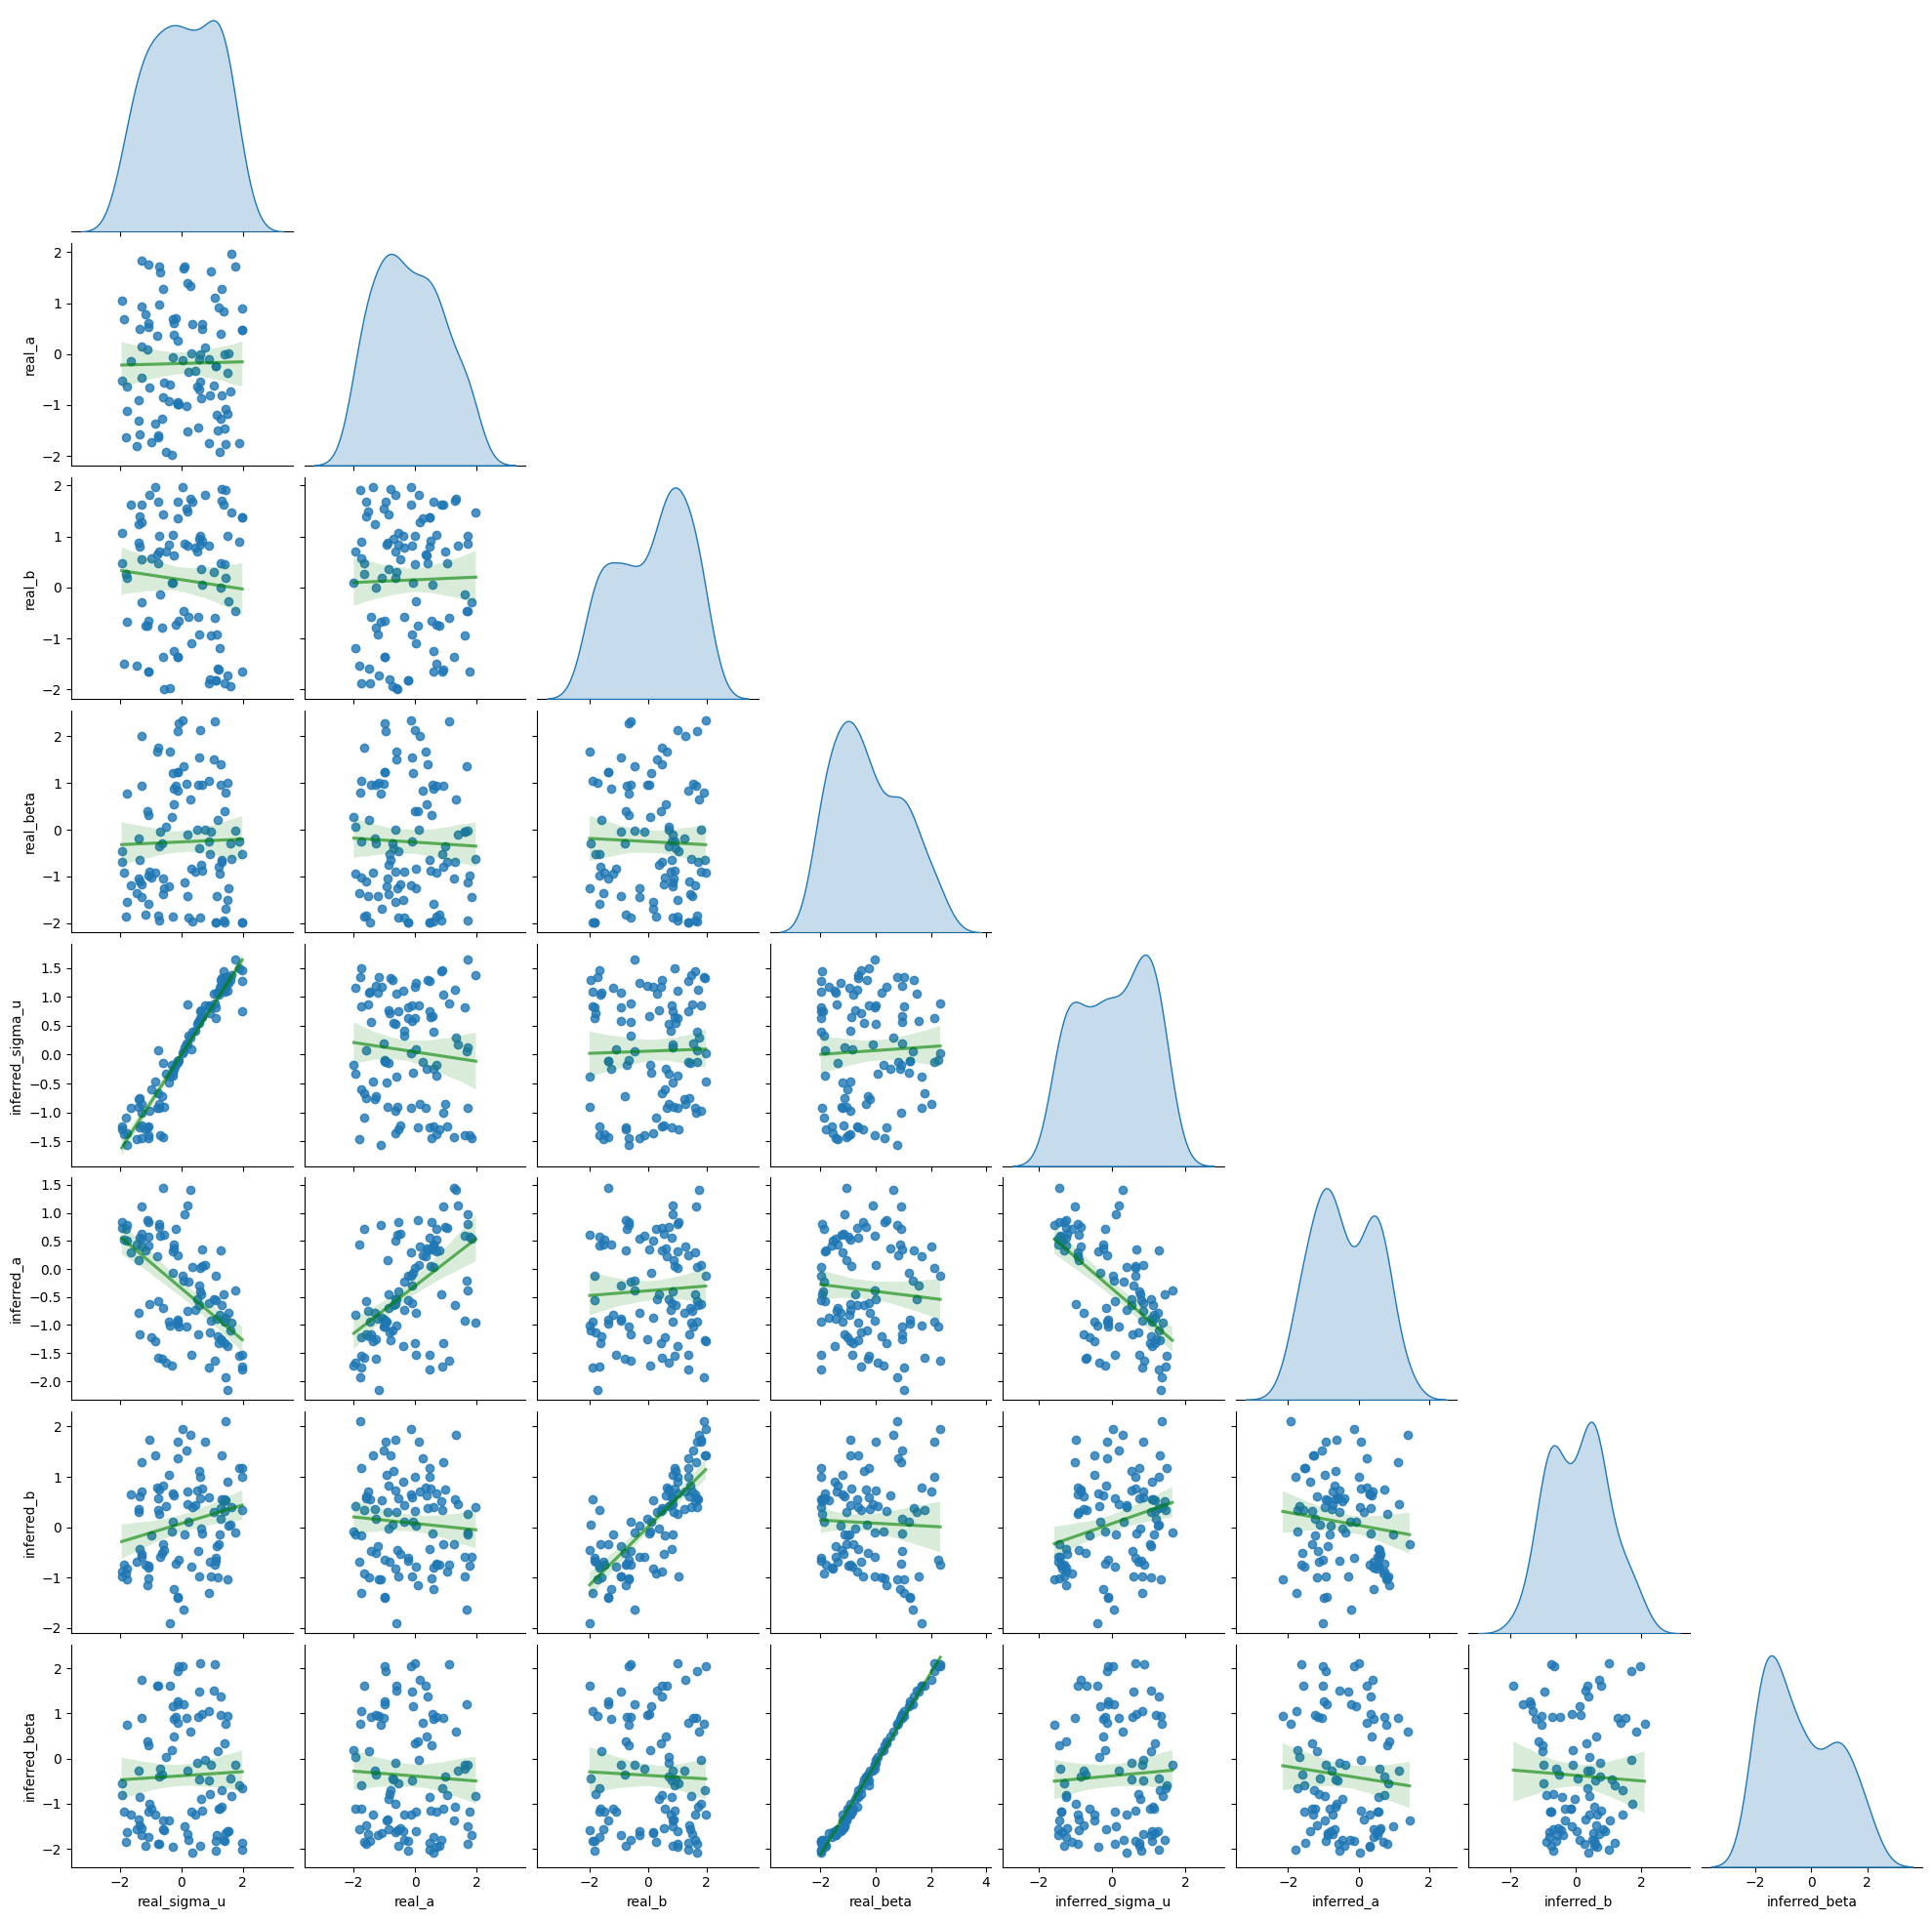

In [61]:
plt.figure()
f = sns.pairplot(data=df, kind='reg', diag_kind="kde", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}})
# f.map(annot_corrfunc)